# 03 — Ablation Experiments

Runs the 7 ablation experiments from `README.md`'s "Ablation Experiments" table.
All numbers here are loaded from `experiments/ablations/results.json`, produced by
`train/ablations.py` (`uv run python train/ablations.py`). Re-run that script to
refresh the numbers this notebook reads.


In [1]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
RESULTS_PATH = os.path.join(ROOT, "experiments", "ablations", "results.json")

with open(RESULTS_PATH) as f:
    results = json.load(f)

# Palette (see .claude dataviz skill): one categorical hue per chart, no dual-axis.
BLUE = "#2a78d6"
GRID = "#e1e0d9"
MUTED = "#898781"
INK = "#0b0b0b"

plt.rcParams.update({
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": INK,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def bar_panel(df, x, ys, titles, xlabel):
    fig, axes = plt.subplots(1, len(ys), figsize=(5 * len(ys), 3.5))
    if len(ys) == 1:
        axes = [axes]
    for ax, y, title in zip(axes, ys, titles):
        ax.bar(df[x].astype(str), df[y], color=BLUE, width=0.55)
        ax.set_title(title, fontsize=11, color=INK)
        ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
        for i, v in enumerate(df[y]):
            ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8, color=INK)
    fig.tight_layout()
    return fig


def line_panel(df, x, ys, titles, xlabel):
    fig, axes = plt.subplots(1, len(ys), figsize=(5 * len(ys), 3.5))
    if len(ys) == 1:
        axes = [axes]
    for ax, y, title in zip(axes, ys, titles):
        ax.plot(df[x], df[y], color=BLUE, marker="o", markersize=6, linewidth=2)
        ax.set_title(title, fontsize=11, color=INK)
        ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    fig.tight_layout()
    return fig


## 1. Masking ratio

Geneformer-style masked gene prediction, swept at 5%, 15%, 25%, 40%. Metrics: best
validation loss (pretraining) and downstream macro-F1 / accuracy (fine-tuning).


,mask_ratio,val_loss,test_macro_f1,test_accuracy
0,0.05,6.282151,0.922029,0.966667
1,0.15,5.971458,0.811975,0.940741
2,0.25,5.816021,0.832487,0.959259
3,0.40,5.711054,0.923496,0.966667


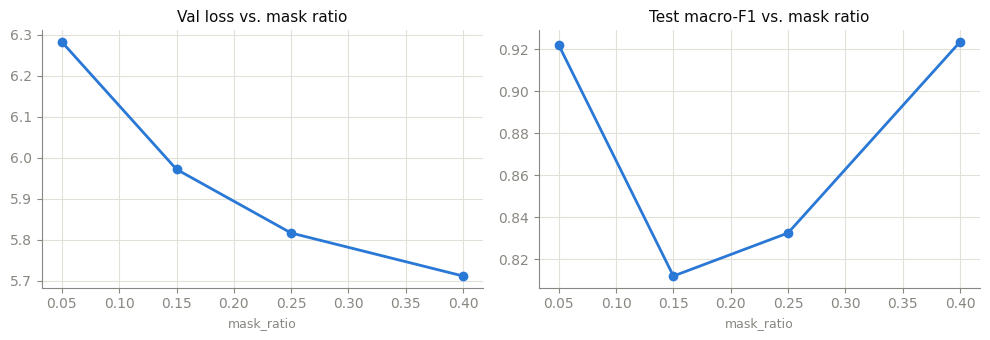

In [2]:
df = pd.DataFrame(results["masking_ratio"])
display(df)
line_panel(df, "mask_ratio", ["val_loss", "test_macro_f1"],
           ["Val loss vs. mask ratio", "Test macro-F1 vs. mask ratio"], "mask_ratio")
plt.show()


## 2. Tokenization

Rank-based (Geneformer-style: gene order encodes expression magnitude) vs.
expression-bin (scBERT-style: fixed gene panel, expression discretized into
quantile bins). Metric: silhouette score of CLS embeddings on a 2D UMAP
projection against true cell type (higher = better-separated clusters).


,tokenization,val_loss,umap_silhouette
0,rank,5.971458,-0.135650
1,expr_bin,0.615904,-0.346494


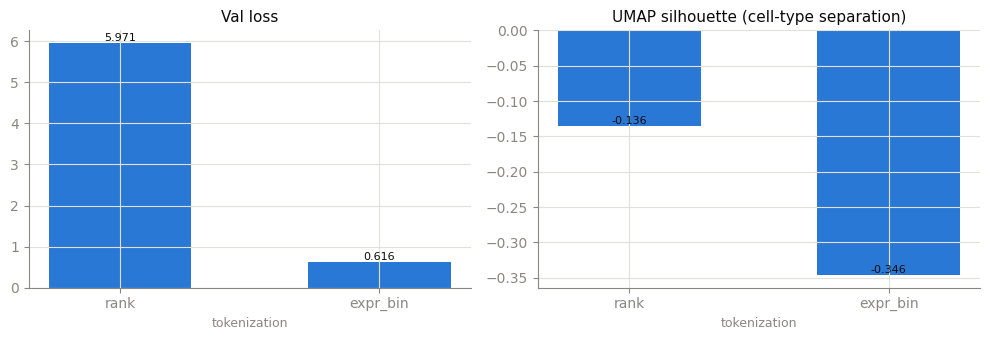

In [3]:
df = pd.DataFrame(results["tokenization"])
display(df)
bar_panel(df, "tokenization", ["val_loss", "umap_silhouette"],
          ["Val loss", "UMAP silhouette (cell-type separation)"], "tokenization")
plt.show()


## 3. Model depth

Transformer encoder depth swept at 2 / 4 / 6 layers (hidden_dim, heads, ffn_dim
held fixed). Metrics: best validation loss and fine-tune test accuracy.


,num_layers,val_loss,test_accuracy
0,2,6.162174,0.951852
1,4,5.971458,0.940741
2,6,5.846766,0.966667


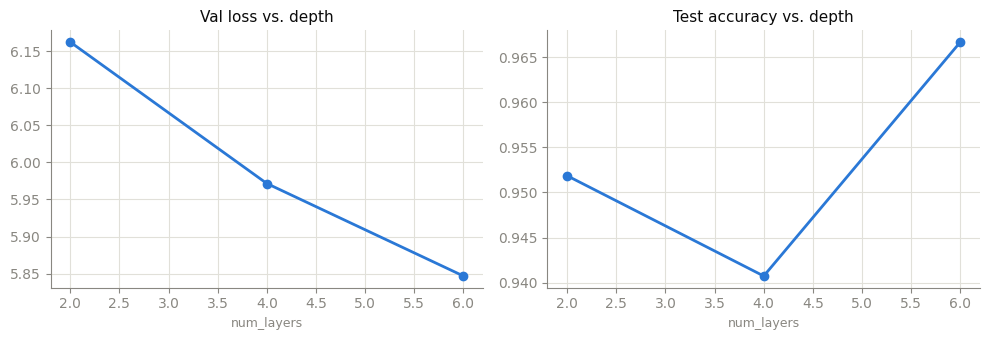

In [4]:
df = pd.DataFrame(results["model_depth"])
display(df)
line_panel(df, "num_layers", ["val_loss", "test_accuracy"],
           ["Val loss vs. depth", "Test accuracy vs. depth"], "num_layers")
plt.show()


## 4. Pretrain vs. scratch

Fine-tuning from the pretrained (masked gene prediction) encoder vs. a
randomly-initialized encoder trained from scratch on the same labelled split.


,condition,test_accuracy
0,pretrained,0.940741
1,scratch,0.951852


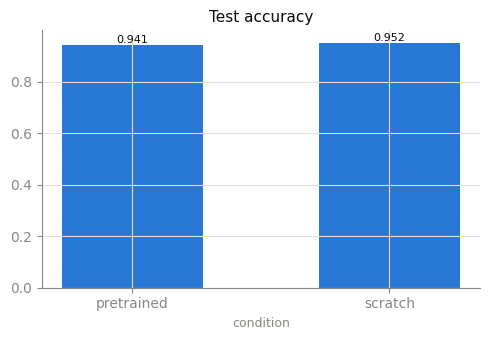

In [5]:
df = pd.DataFrame(results["pretrain_vs_scratch"])
display(df)
bar_panel(df, "condition", ["test_accuracy"], ["Test accuracy"], "condition")
plt.show()


## 5. Freeze vs. fine-tune

Freezing the entire pretrained encoder (`freeze_encoder="full"`, only the
classification head trains) vs. full end-to-end fine-tuning (`"none"`).


,freeze_encoder,test_accuracy
0,none,0.940741
1,full,0.600000


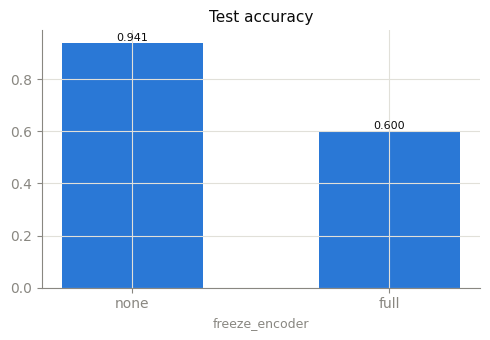

In [6]:
df = pd.DataFrame(results["freeze_vs_finetune"])
display(df)
bar_panel(df, "freeze_encoder", ["test_accuracy"], ["Test accuracy"], "freeze_encoder")
plt.show()


## 6. Gene embeddings

Plain `nn.Embedding` baseline vs. GeneGAT over the STRING PPI graph (frozen after
init, or trained jointly end-to-end). Metrics: fine-tune test accuracy and CLS
embedding UMAP silhouette.


,condition,test_accuracy,umap_silhouette
0,baseline,0.940741,-0.135650
1,gnn_frozen,0.925926,-0.110870
2,gnn_joint,0.933333,-0.096692


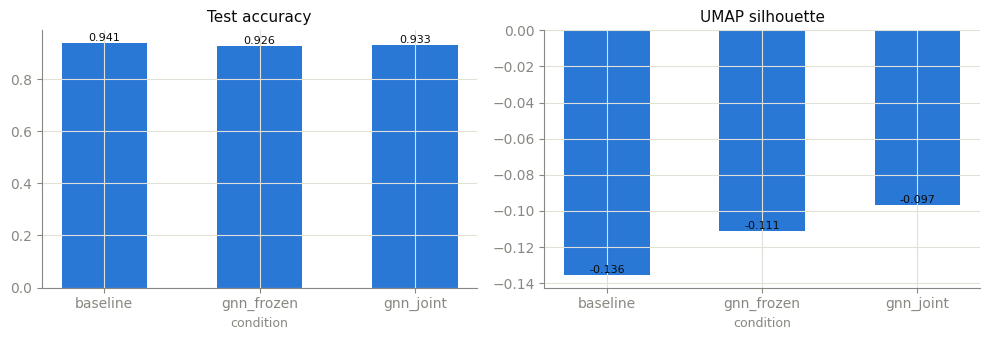

In [7]:
df = pd.DataFrame(results["gene_embeddings"])
display(df)
bar_panel(df, "condition", ["test_accuracy", "umap_silhouette"],
          ["Test accuracy", "UMAP silhouette"], "condition")
plt.show()


## 7. Classification head

`[CLS]` linear probe vs. CellGAT (GNN-as-classifier: PPI graph used during
classification itself, not just embedding init).


,head,test_accuracy
0,cls,0.940741
1,gat,0.944444


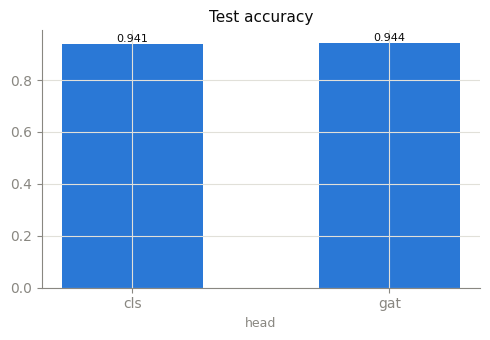

In [8]:
df = pd.DataFrame(results["classification_head"])
display(df)
bar_panel(df, "head", ["test_accuracy"], ["Test accuracy"], "head")
plt.show()
